# OPV light-intensity dependant JV fits with SIMsalabim (fake data)
This notebook is a demonstration of how to fit light-intensity dependent JV curves with drift-diffusion models using the [SIMsalabim](https://github.com/kostergroup/SIMsalabim) package.

In [1]:
# Import necessary libraries
import warnings, os, sys, shutil
# remove warnings from the output
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
import torch, copy, uuid
import pySIMsalabim as sim
from pySIMsalabim.experiments.JV_steady_state import *
import ax, logging
from ax.utils.notebook.plotting import init_notebook_plotting, render
init_notebook_plotting() # for Jupyter notebooks

try:
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *
except Exception as e:
    sys.path.append('../') # add the path to the optimpv module
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *

[INFO 03-30 17:23:40] ax.utils.notebook.plotting: Injecting Plotly library into cell. Do not overwrite or delete cell.
[INFO 03-30 17:23:40] ax.utils.notebook.plotting: Please see
    (https://ax.dev/tutorials/visualizations.html#Fix-for-plots-that-are-not-rendering)
    if visualizations are not rendering.


## Define the parameters for the simulation

In [2]:
params = [] # list of parameters to be optimized

mun = FitParam(name = 'l2.mu_n', value = 7e-8, bounds = [1e-9,1e-6], log_scale = True, value_type = 'float', fscale = None, rescale = False, display_name=r'$\mu_n$', unit='m$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', force_log = True)
params.append(mun)

mup = FitParam(name = 'l2.mu_p', value = 5e-8, bounds = [1e-9,1e-6], log_scale = True, value_type = 'float', fscale = None, rescale = False, display_name=r'$\mu_p$', unit=r'm$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', force_log = True)
params.append(mup)

bulk_tr = FitParam(name = 'l2.N_t_bulk', value = 1e20, bounds = [1e19,1e22], log_scale = True, value_type = 'float', fscale = None, rescale = False,  display_name=r'$N_{T}$', unit=r'm$^{-3}$', axis_type = 'log', force_log = False)
params.append(bulk_tr)

preLangevin = FitParam(name = 'l2.preLangevin', value = 1e-2, bounds = [0.005,1], log_scale = True, value_type = 'float', fscale = None, rescale = False, display_name=r'$\gamma_{pre}$', unit=r'', axis_type = 'log', force_log = False)
params.append(preLangevin)

R_series = FitParam(name = 'R_series', value = 1e-4, bounds = [1e-5,1e-3], log_scale = True, value_type = 'float', fscale = None, rescale = False,  display_name=r'$R_{series}$', unit=r'$\Omega$ m$^2$', axis_type = 'log', force_log = False)
params.append(R_series)

# save the original parameters for later
params_orig = copy.deepcopy(params)
num_free_params = len([p for p in params if p.type != 'fixed'])

## Generate some fake data
Here we generate some fake data to fit. The data is generated using the same model as the one used for the fitting, so it is a good test of the fitting procedure. For more information on how to run SIMsalabim from python see the [pySIMsalabim](https://github.com/kostergroup/pySIMsalabim) package.

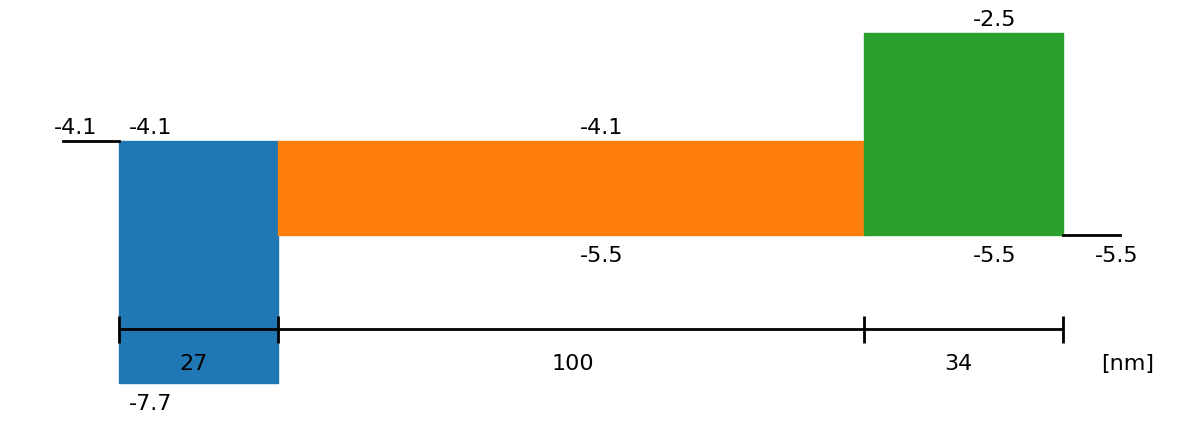

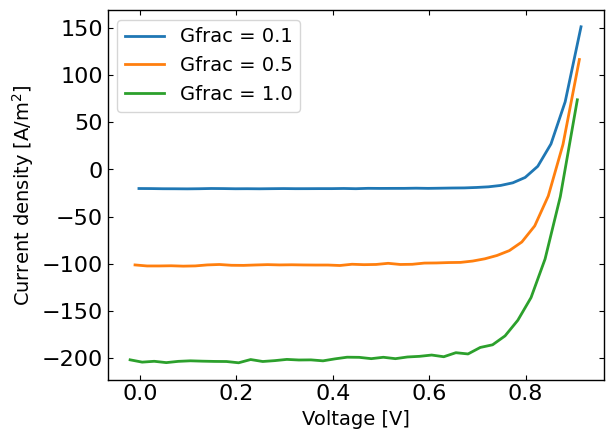

In [3]:
# Set the session path for the simulation and the input files
session_path = os.path.join(os.path.join(os.path.abspath('../'),'SIMsalabim','SimSS'))
input_path = os.path.join(os.path.join(os.path.join(os.path.abspath('../'),'Data','simsalabim_test_inputs','fakeOPV')))
simulation_setup_filename = 'simulation_setup_fakeOPV.txt'
simulation_setup = os.path.join(session_path, simulation_setup_filename) 

# path to the layer files defined in the simulation_setup file
l1 = 'ZnO.txt'
l2 = 'ActiveLayer.txt'
l3 = 'BM_HTL.txt'
l1 = os.path.join(input_path, l1)
l2 = os.path.join(input_path, l2)
l3 = os.path.join(input_path, l3)

# copy this files to session_path
force_copy = True
if not os.path.exists(session_path):
    os.makedirs(session_path)
for file in [l1,l2,l3,simulation_setup_filename]:
    file = os.path.join(input_path, os.path.basename(file))
    if force_copy or not os.path.exists(os.path.join(session_path, os.path.basename(file))):
        shutil.copyfile(file, os.path.join(session_path, os.path.basename(file)))
    else:
        print('File already exists: ',file)

# Show the device structure
fig = sim.plot_band_diagram(simulation_setup, session_path)

# reset simss
# Set the JV parameters
Gfracs = [0.1,0.5,1.0] # Fractions of the generation rate to simulate (None if you want only one light intensity as define in the simulation_setup file)
UUID = str(uuid.uuid4()) # random UUID to avoid overwriting files

cmd_pars = [] # see pySIMsalabim documentation for the command line parameters
# Add the parameters to the command line arguments
for param in params:
    cmd_pars.append({'par':param.name, 'val':str(param.value)})

# Run the JV simulation
ret, mess = run_SS_JV(simulation_setup, session_path, JV_file_name = 'JV.dat', G_fracs = Gfracs, parallel = True, max_jobs = 3, UUID=UUID, cmd_pars=cmd_pars)

# save data for fitting
X,y = [],[]
X_orig,y_orig = [],[]
if Gfracs is None:
    data = pd.read_csv(os.path.join(session_path, 'JV_'+UUID+'.dat'), sep=r'\s+') # Load the data
    Vext = np.asarray(data['Vext'].values)
    Jext = np.asarray(data['Jext'].values)
    G = np.ones_like(Vext)
    rng = default_rng()#
    noise = rng.standard_normal(Jext.shape) * 0.01 * Jext
    Jext = Jext + noise
    X = Vext
    y = Jext

    plt.figure()
    plt.plot(X,y)
    plt.show()
else:
    for Gfrac in Gfracs:
        data = pd.read_csv(os.path.join(session_path, 'JV_Gfrac_'+str(Gfrac)+'_'+UUID+'.dat'), sep=r'\s+') # Load the data
        Vext = np.asarray(data['Vext'].values)
        Jext = np.asarray(data['Jext'].values)
        G = np.ones_like(Vext)*Gfrac
        rng = default_rng()#
        noise = rng.standard_normal(Jext.shape) * 0.005 * Jext

        if len(X) == 0:
            X = np.vstack((Vext,G)).T
            y = Jext + noise
            y_orig = Jext 
        else:
            X = np.vstack((X,np.vstack((Vext,G)).T))
            y = np.hstack((y,Jext+ noise))
            y_orig = np.hstack((y_orig,Jext))

    # remove all the current where Jext is higher than a given value
    X = X[y<200]
    X_orig = copy.deepcopy(X)
    y_orig = y_orig[y<200]
    y = y[y<200]
    
    

    plt.figure()
    for Gfrac in Gfracs:
        plt.plot(X[X[:,1]==Gfrac,0],y[X[:,1]==Gfrac],label='Gfrac = '+str(Gfrac))
    plt.xlabel('Voltage [V]')
    plt.ylabel('Current density [A/m$^2$]')
    plt.legend()
    plt.show()



## Run the optimization

In [4]:
# Define the Agent and the target metric/loss function
from optimpv.models.DDfits.JVAgent import JVAgent
metric = 'nrmse' # can be 'nrmse', 'mse', 'mae'
loss = 'linear' # can be 'linear', 'huber', 'soft_l1'

jv = JVAgent(params, X, y, session_path, simulation_setup, parallel = True, max_jobs = 3, metric = metric, loss = loss)

# Calulate the target metric for the original parameters
best_fit_possible = loss_function(calc_metric(y,y_orig, metric_name = metric),loss)
print('Best fit: ',best_fit_possible)

Best fit:  0.0019660866767641774


In [5]:
from optimpv.optimizers.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer

model_kwargs_list = [
    {},
    {
        'torch_device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        'torch_dtype': torch.double,
        'acq': 'ts', # acquisition function in local TuRBO: 'EI' or 'TS'
        "n_trust_regions": 4, # 1:TuRBO-1, m>1:TuRBO-m
        "region_init_points": 4, # number of initial sample points when TuRBO starts with REI
        "racqf": "QREI",   # region-averaged acquisition function: single-region fallback is REI, multi-region seeding is forced to QREI
    },
]

optimizer = axBOtorchOptimizer(params = params, agents = jv, models = ['SOBOL','REITURBO'],n_batches = [1,200], batch_size = [10,2], model_kwargs_list = model_kwargs_list)



In [6]:
%%time
optimizer.optimize() # run the optimization with ax

[INFO 03-30 17:23:40] optimpv.axBOtorchOptimizer: Trial 0 with parameters: {'l2.mu_n': -8.32874746620655, 'l2.mu_p': -6.95187091268599, 'l2.N_t_bulk': 2.1253327051368017e+21, 'l2.preLangevin': 0.008546184431403769, 'R_series': 0.0003134415012863306}
[INFO 03-30 17:23:40] optimpv.axBOtorchOptimizer: Trial 1 with parameters: {'l2.mu_n': -6.340679221786559, 'l2.mu_p': -7.981186045333743, 'l2.N_t_bulk': 1.2008283257412479e+20, 'l2.preLangevin': 0.5321097044259594, 'R_series': 1.2471674635162862e-05}
[INFO 03-30 17:23:40] optimpv.axBOtorchOptimizer: Trial 2 with parameters: {'l2.mu_n': -7.298721419647336, 'l2.mu_p': -6.7172024063766, 'l2.N_t_bulk': 7.896326246441404e+20, 'l2.preLangevin': 0.06720503906836325, 'R_series': 4.689157256320726e-05}
[INFO 03-30 17:23:40] optimpv.axBOtorchOptimizer: Trial 3 with parameters: {'l2.mu_n': -8.126633296720684, 'l2.mu_p': -8.308857344090939, 'l2.N_t_bulk': 4.9715449022618984e+19, 'l2.preLangevin': 0.07991294177611985, 'R_series': 0.0006279819605571275}


CPU times: user 7min 57s, sys: 2.98 s, total: 8min
Wall time: 2min 14s


In [7]:
# get the best parameters and update the params list in the optimizer and the agent
ax_client = optimizer.ax_client # get the ax client
optimizer.update_params_with_best_balance() # update the params list in the optimizer with the best parameters
jv.params = optimizer.params # update the params list in the agent with the best parameters

# print the best parameters
print('Best parameters:')
for p,po in zip(optimizer.params, params_orig):
    print(p.name, 'fitted value:', p.value, 'original value:', po.value)
    
print('\nSimSS command line:')
print(jv.get_SIMsalabim_clean_cmd(jv.params)) # print the simss command line with the best parameters


Best parameters:
l2.mu_n fitted value: 9.385790490159223e-08 original value: 7e-08
l2.mu_p fitted value: 3.349687597809106e-08 original value: 5e-08
l2.N_t_bulk fitted value: 8.25681756310049e+19 original value: 1e+20
l2.preLangevin fitted value: 0.009961751355138656 original value: 0.01
R_series fitted value: 9.60338617084351e-05 original value: 0.0001

SimSS command line:
./simss -l2.mu_n 9.385790490159223e-08 -l2.mu_p 3.349687597809106e-08 -l2.N_t_bulk 8.25681756310049e+19 -l2.preLangevin 0.009961751355138656 -R_series 9.60338617084351e-05


Best value seen so far is  0.0038565649281323863 at iteration  149
Best value possible is  0.0019660866767641774


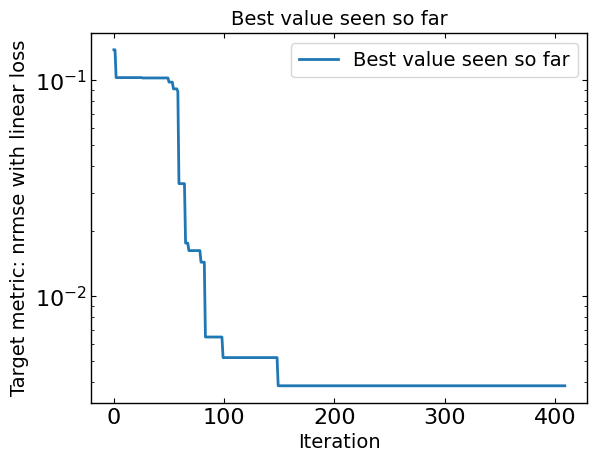

In [8]:
# Plot optimization results
data = ax_client.summarize()
all_metrics = optimizer.all_metrics
plt.figure()
plt.plot(np.minimum.accumulate(data[all_metrics]), label="Best value seen so far")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Target metric: " + metric + " with " + loss + " loss")
plt.legend()
plt.title("Best value seen so far")

print("Best value seen so far is ", min(data[all_metrics[0]]), "at iteration ", int(data[all_metrics[0]].idxmin()))
print("Best value possible is ", best_fit_possible)
plt.show()

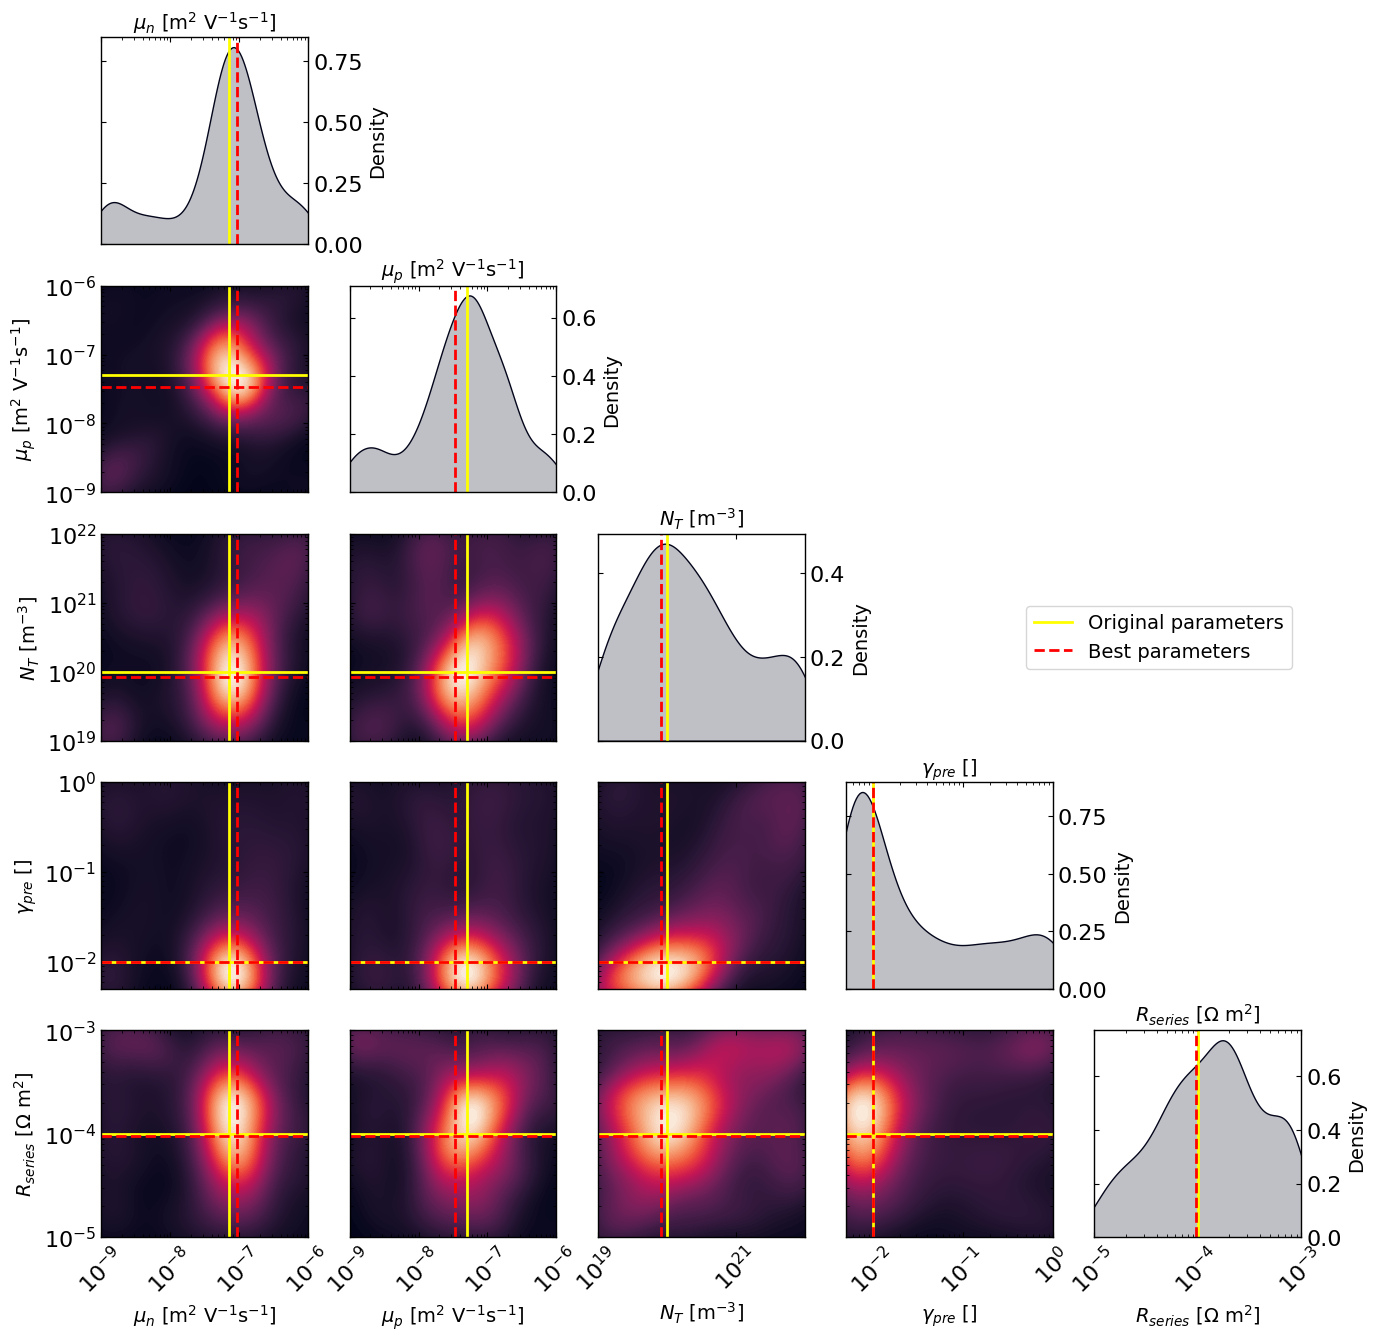

In [9]:
# Plot the density of the exploration of the parameters
# this gives a nice visualization of where the optimizer focused its exploration and may show some correlation between the parameters
plot_dens = True
if plot_dens:
    from optimpv.posterior.exploration_density import *
    params_orig_dict, best_parameters = {}, {}
    for p in params_orig:
        params_orig_dict[p.name] = p.value
    for p in optimizer.params:
        best_parameters[p.name] = p.value

    fig_dens, ax_dens = plot_density_exploration(params, optimizer = optimizer, best_parameters = best_parameters, params_orig = params_orig_dict, optimizer_type = 'ax')


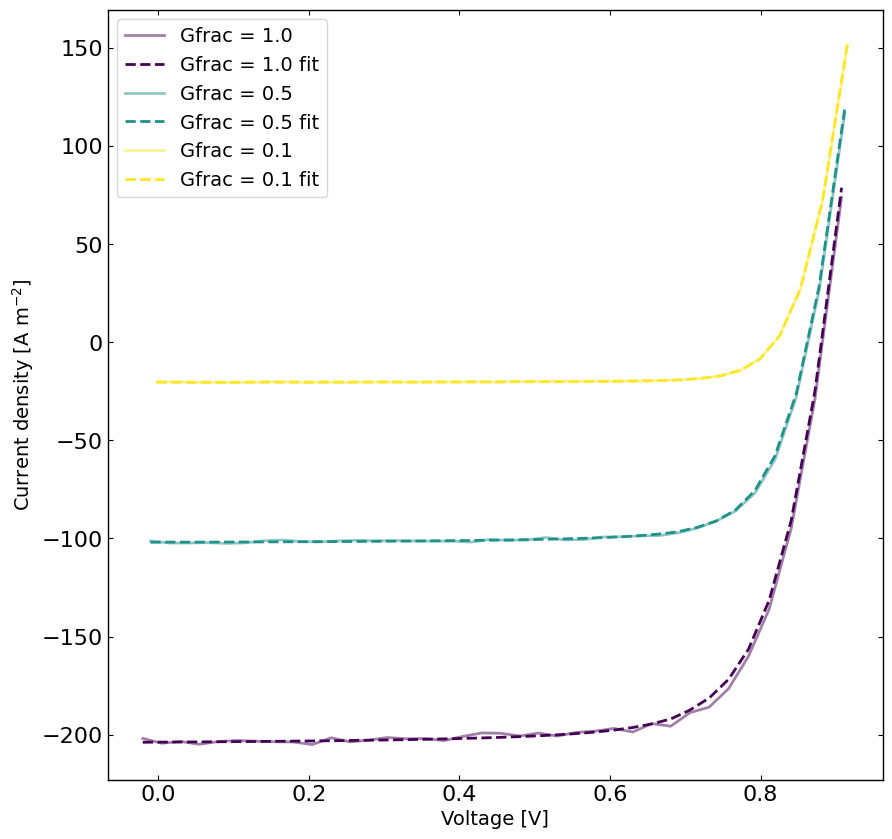

In [10]:
# rerun the simulation with the best parameters
yfit = jv.run(parameters={}) # run the simulation with the best parameters

viridis = plt.get_cmap('viridis', len(Gfracs))
plt.figure(figsize=(10,10))
linewidth = 2
for idx, Gfrac in enumerate(Gfracs[::-1]):
    plt.plot(X[X[:,1]==Gfrac,0],y[X[:,1]==Gfrac],label='Gfrac = '+str(Gfrac),color=viridis(idx),alpha=0.5,linewidth=linewidth)
    plt.plot(X[X[:,1]==Gfrac,0],yfit[X[:,1]==Gfrac],label='Gfrac = '+str(Gfrac)+' fit',linestyle='--',color=viridis(idx),linewidth=linewidth)
plt.xlabel('Voltage [V]')
plt.ylabel('Current density [A m$^{-2}$]')
plt.legend()
plt.show()

In [11]:
# Clean up the output files (comment out if you want to keep the output files)
sim.clean_all_output(session_path)
sim.delete_folders('tmp',session_path)
# uncomment the following lines to delete specific files
sim.clean_up_output('ZnO',session_path)
sim.clean_up_output('ActiveLayer',session_path)
sim.clean_up_output('BM_HTL',session_path)
sim.clean_up_output('simulation_setup_fakeOPV',session_path)